 Loading Oxford Flowers 102 dataset...


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)


 Training initial classifier (frozen base)...
Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 24s 460ms/step - accuracy: 0.0432 - loss: 4.7993 - val_accuracy: 0.2652 - val_loss: 3.5205
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 359ms/step - accuracy: 0.3575 - loss: 2.9216 - val_accuracy: 0.4902 - val_loss: 2.3419
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 362ms/step - accuracy: 0.5537 - loss: 1.8244 - val_accuracy: 0.5741 - val_loss: 1.8403
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 360ms/step - accuracy: 0.6877 - loss: 1.1560 - val_accuracy: 0.6201 - val_loss: 1.5440
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 360ms/step - accuracy: 0.7577 - loss: 0.8869 - val_accuracy: 0.6517 - val_loss: 1.4058
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 364ms/step - accuracy: 0.8336 - loss: 0.6937 - val_accuracy: 0.6661 - val_loss: 1.3303
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 364ms/step - accuracy: 0.8695 - loss: 0.5310 - val_accuracy: 0.6686 - val_loss: 1.2912
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 362ms/st

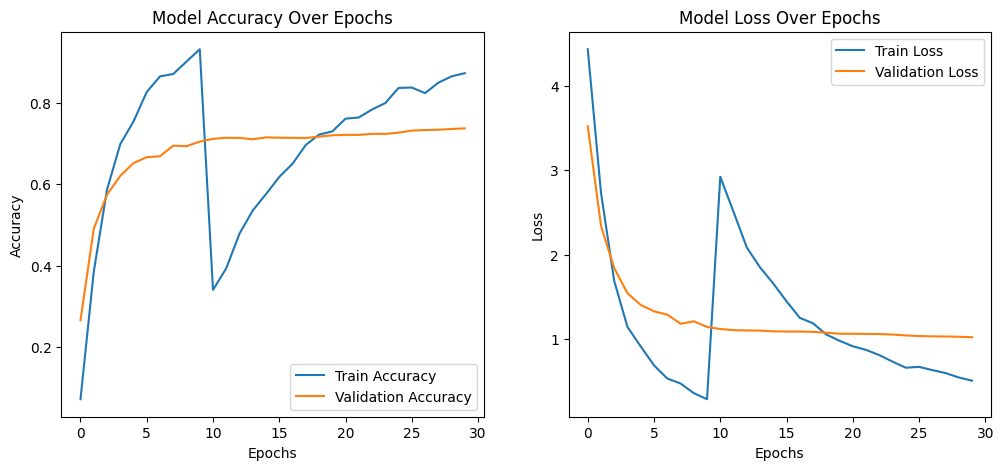

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


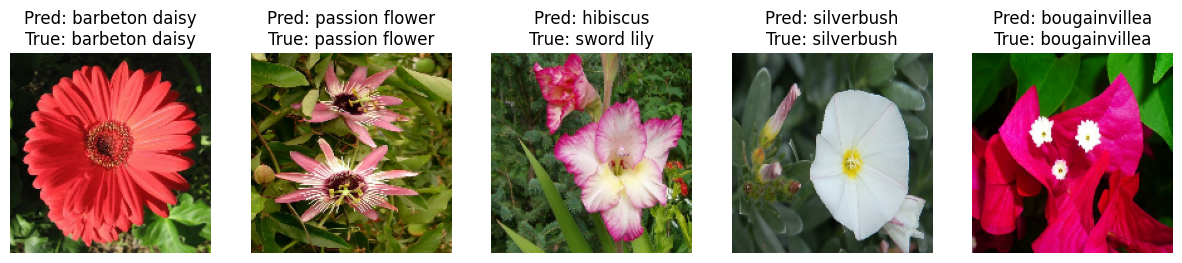

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np

print(" Loading Oxford Flowers 102 dataset...")
dataset, info = tfds.load("oxford_flowers102", with_info=True, as_supervised=True)
train_ds, test_ds = dataset["train"], dataset["test"]

val_size = 0.2
IMG_SIZE = 160
BATCH_SIZE = 32

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_ds = train_ds.map(preprocess).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

model = models.Sequential([
    data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(102, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

print("\n Training initial classifier (frozen base)...")
history_1 = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10
)

print("\n Fine-tuning MobileNetV2 layers...")
base_model.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


history_2 = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=20
)


history = {
    'accuracy': history_1.history['accuracy'] + history_2.history['accuracy'],
    'val_accuracy': history_1.history['val_accuracy'] + history_2.history['val_accuracy'],
    'loss': history_1.history['loss'] + history_2.history['loss'],
    'val_loss': history_1.history['val_loss'] + history_2.history['val_loss']
}


test_loss, test_acc = model.evaluate(test_ds)
print(f"\n Final Test Accuracy: {test_acc:.4f}")
print(f" Final Test Loss: {test_loss:.4f}")


plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history['accuracy'], label='Train Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history['loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


label_names = info.features['label'].names
sample_images, sample_labels = next(iter(test_ds.unbatch().batch(5)))
predictions = model.predict(sample_images)

plt.figure(figsize=(15,5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(sample_images[i])
    pred_label = label_names[np.argmax(predictions[i])]
    true_label = label_names[int(sample_labels[i])]
    plt.title(f"Pred: {pred_label}\nTrue: {true_label}")
    plt.axis('off')
plt.show()
